In [ ]:
import pandas as pd
import numpy as np

In [ ]:
period_log = pd.read_csv(r"/content/Period_Log.csv")
user_profile = pd.read_csv(r"/content/User_Profile.csv")

In [ ]:
# Make sure pandas shows all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)


print("Period Log Data:")
print(period_log.head())


print("\nUser Profile Data:")
print(user_profile.head())

Period Log Data:
  user_id  cycle_number  start_date  cycle_length_days  prev_cycle_length cycle_phase flow_level  pain_level pms_symptoms  mood_score  stress_score_cycle  sleep_hours_cycle  energy_level  concentration_score  work_hours_lost  estrogen_pgml  progesterone_ngml ovulation_result  overall_health_score  log_consistency_score  prepared_before_period
0  U00001             1  2024-02-13                 33                NaN      Luteal      Heavy           9          Yes           6                 5.4                5.3             6                    7              5.1           84.7               4.14         Positive                   6.5                  0.949                       0
1  U00001             2  2024-03-17                 33               33.0  Follicular      Light           2           No           8                 3.7                4.6             7                    8              2.6          126.1               2.79         Negative                  

In [ ]:
print("\nPeriod Log Info:")
print(period_log.info())

print("\nUser Profile Info:")
print(user_profile.info())


Period Log Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17976 entries, 0 to 17975
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 17976 non-null  object 
 1   cycle_number            17976 non-null  int64  
 2   start_date              17976 non-null  object 
 3   cycle_length_days       17976 non-null  int64  
 4   prev_cycle_length       15976 non-null  float64
 5   cycle_phase             17976 non-null  object 
 6   flow_level              17976 non-null  object 
 7   pain_level              17976 non-null  int64  
 8   pms_symptoms            17976 non-null  object 
 9   mood_score              17976 non-null  int64  
 10  stress_score_cycle      17976 non-null  float64
 11  sleep_hours_cycle       17976 non-null  float64
 12  energy_level            17976 non-null  int64  
 13  concentration_score     17976 non-null  int64  
 14  work_hours_lost     

In [ ]:
print("\nMissing values in Period Log:")
print(period_log.isnull().sum())


print("\nMissing values in User Profile:")
print(user_profile.isnull().sum())


Missing values in Period Log:
user_id                      0
cycle_number                 0
start_date                   0
cycle_length_days            0
prev_cycle_length         2000
cycle_phase                  0
flow_level                   0
pain_level                   0
pms_symptoms                 0
mood_score                   0
stress_score_cycle           0
sleep_hours_cycle            0
energy_level                 0
concentration_score          0
work_hours_lost              0
estrogen_pgml                0
progesterone_ngml            0
ovulation_result             0
overall_health_score         0
log_consistency_score        0
prepared_before_period       0
dtype: int64

Missing values in User Profile:
user_id                    0
state                      0
age                        0
bmi                        0
diet_quality               0
exercise_frequency       385
sleep_hours                0
caffeine_intake            0
water_intake_liters        0
alcohol_con

In [ ]:
# Make sure pandas shows all columns in one line
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
# Merge datasets using 'user_id'
# 'left' join ensures we keep all cycle-level data
merged_data = pd.merge(period_log, user_profile, on='user_id', how='left')

# View merged data
print("\nMerged Data Preview:")
print(merged_data.head())


Merged Data Preview:
  user_id  cycle_number  start_date  cycle_length_days  prev_cycle_length cycle_phase flow_level  pain_level pms_symptoms  mood_score  stress_score_cycle  sleep_hours_cycle  energy_level  concentration_score  work_hours_lost  estrogen_pgml  progesterone_ngml ovulation_result  overall_health_score  log_consistency_score  prepared_before_period         state  age   bmi diet_quality exercise_frequency  sleep_hours  caffeine_intake  water_intake_liters alcohol_consumption smoking_status  birth_control_use  pcos_diagnosed  stress_score_baseline
0  U00001             1  2024-02-13                 33                NaN      Luteal      Heavy           9          Yes           6                 5.4                5.3             6                    7              5.1           84.7               4.14         Positive                   6.5                  0.949                       0  Rhode Island   34  26.0         Good      5–6 days/week          5.4              1.5 

In [ ]:
# Check number of rows before and after merge
print("\nRows in Period Log:", len(period_log))
print("Rows in Merged Data:", len(merged_data))

# If both are equal → merge is correct


Rows in Period Log: 17976
Rows in Merged Data: 17976


In [ ]:
# Convert Yes/No to 1/0
merged_data['pms_symptoms'] = merged_data['pms_symptoms'].map({'Yes': 1, 'No': 0})
merged_data['ovulation_result'] = merged_data['ovulation_result'].map({'Positive': 1, 'Negative': 0})

In [ ]:
# Convert cycle_phase into dummy variables
merged_data = pd.get_dummies(merged_data, columns=['cycle_phase'], drop_first=True)

# Convert flow_level into dummy variables
merged_data = pd.get_dummies(merged_data, columns=['flow_level'], drop_first=True)

# Convert diet_quality into dummy variables
merged_data = pd.get_dummies(merged_data, columns=['diet_quality'], drop_first=True)

# Convert alcohol_consumption into dummy variables
merged_data = pd.get_dummies(merged_data, columns=['alcohol_consumption'], drop_first=True)

# Convert smoking_status into dummy variables
merged_data = pd.get_dummies(merged_data, columns=['smoking_status'], drop_first=True)

In [ ]:
# Convert exercise frequency into numeric scale
exercise_map = {
    '1–2 days/week': 1,
    '3–4 days/week': 2,
    '5–6 days/week': 3
}

merged_data['exercise_frequency'] = merged_data['exercise_frequency'].map(exercise_map)

In [ ]:
# Check final dataset after preprocessing
print("\nFinal Dataset Info:")
print(merged_data.info())

# View sample data
print("\nFinal Dataset Preview:")
merged_data


Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17976 entries, 0 to 17975
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           17976 non-null  object 
 1   cycle_number                      17976 non-null  int64  
 2   start_date                        17976 non-null  object 
 3   cycle_length_days                 17976 non-null  int64  
 4   prev_cycle_length                 15976 non-null  float64
 5   pain_level                        17976 non-null  int64  
 6   pms_symptoms                      17976 non-null  int64  
 7   mood_score                        17976 non-null  int64  
 8   stress_score_cycle                17976 non-null  float64
 9   sleep_hours_cycle                 17976 non-null  float64
 10  energy_level                      17976 non-null  int64  
 11  concentration_score               17976 non-nu

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,pain_level,pms_symptoms,mood_score,stress_score_cycle,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period,state,age,bmi,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,birth_control_use,pcos_diagnosed,stress_score_baseline,cycle_phase_Luteal,cycle_phase_Menstrual,flow_level_Light,flow_level_Moderate,diet_quality_Excellent,diet_quality_Good,diet_quality_Poor,alcohol_consumption_Occasionally,alcohol_consumption_Weekly,smoking_status_Yes
0,U00001,1,2024-02-13,33,NaN,9,1,6,5.4,5.3,6,7,5.1,84.7,4.14,1,6.5,0.949,0,Rhode Island,34,26.0,3.0,5.4,1.5,2.0,1,1,4.1,True,False,False,False,False,True,False,True,False,False
1,U00001,2,2024-03-17,33,33.0,2,0,8,3.7,4.6,7,8,2.6,126.1,2.79,0,9.4,0.949,1,Rhode Island,34,26.0,3.0,5.4,1.5,2.0,1,1,4.1,False,False,True,False,False,True,False,True,False,False
2,U00001,3,2024-04-19,34,33.0,8,0,5,5.7,5.1,5,5,6.8,131.1,1.70,0,6.7,0.949,1,Rhode Island,34,26.0,3.0,5.4,1.5,2.0,1,1,4.1,False,False,False,False,False,True,False,True,False,False
3,U00001,4,2024-05-23,31,34.0,3,0,8,5.2,6.7,8,8,2.5,82.0,8.50,0,9.0,0.949,0,Rhode Island,34,26.0,3.0,5.4,1.5,2.0,1,1,4.1,True,False,True,False,False,True,False,True,False,False
4,U00001,5,2024-06-23,31,31.0,3,0,9,3.7,5.8,9,8,2.4,55.5,6.30,0,9.3,0.949,1,Rhode Island,34,26.0,3.0,5.4,1.5,2.0,1,1,4.1,True,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17971,U02000,6,2024-07-06,26,26.0,6,0,7,6.0,5.2,6,7,5.3,77.5,5.31,0,8.1,0.946,1,Hawaii,24,20.1,1.0,4.9,2.3,2.3,1,0,6.7,True,False,False,True,False,True,False,True,False,False
17972,U02000,7,2024-08-01,27,26.0,6,1,7,8.2,5.6,8,6,3.0,65.5,0.74,1,7.6,0.946,1,Hawaii,24,20.1,1.0,4.9,2.3,2.3,1,0,6.7,False,True,False,True,False,True,False,True,False,False
17973,U02000,8,2024-08-28,30,27.0,6,0,5,7.6,4.5,6,7,4.6,51.9,1.26,0,7.6,0.946,0,Hawaii,24,20.1,1.0,4.9,2.3,2.3,1,0,6.7,False,True,False,True,False,True,False,True,False,False
17974,U02000,9,2024-09-27,29,30.0,3,0,8,7.2,4.9,6,8,3.0,85.3,8.99,1,8.8,0.946,1,Hawaii,24,20.1,1.0,4.9,2.3,2.3,1,0,6.7,True,False,True,False,False,True,False,True,False,False


In [ ]:
# Check unique users
print("\nNumber of unique users:", merged_data['user_id'].nunique())

# Check number of rows per user (should be ~10–12)
print("\nCycles per user:")
print(merged_data['user_id'].value_counts())


Number of unique users: 2000

Cycles per user:
user_id
U01958    12
U01960    12
U01236    12
U01238    12
U00562    12
          ..
U01410     6
U00005     6
U01976     6
U01974     6
U01973     6
Name: count, Length: 2000, dtype: int64


In [ ]:
import statsmodels.api as sm

import statsmodels.formula.api as smf

In [ ]:
# Drop rows with missing values in key variables

merged_data = merged_data.dropna(subset=[
    'pain_level',
    'stress_score_cycle',
    'sleep_hours_cycle',
    'estrogen_pgml',
    'progesterone_ngml'
])

# Check remaining data
print("Remaining rows after cleaning:", len(merged_data))

Remaining rows after cleaning: 17976


In [ ]:
# MODEL 1: Only biological variables

model1 = smf.ols(
    formula="""
    pain_level ~ estrogen_pgml + progesterone_ngml
    + cycle_phase_Luteal + cycle_phase_Menstrual
    """,
    data=merged_data
).fit()


print("\nMODEL 1 SUMMARY (Biological):")
print(model1.summary())


MODEL 1 SUMMARY (Biological):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     22.91
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           6.61e-19
Time:                        11:01:18   Log-Likelihood:                -39880.
No. Observations:               17976   AIC:                         7.977e+04
Df Residuals:                   17971   BIC:                         7.981e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [ ]:
# MODEL 2: Add psychological factors

model2 = smf.ols(
    formula="""
    pain_level ~ estrogen_pgml + progesterone_ngml
    + cycle_phase_Luteal + cycle_phase_Menstrual
    + stress_score_cycle + sleep_hours_cycle + mood_score
    """,
    data=merged_data
).fit()

print("\nMODEL 2 SUMMARY (Biological + Psychological):")
print(model2.summary())


MODEL 2 SUMMARY (Biological + Psychological):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     2726.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:01:19   Log-Likelihood:                -33421.
No. Observations:               17976   AIC:                         6.686e+04
Df Residuals:                   17968   BIC:                         6.692e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
# MODEL 3: Add lifestyle factors

model3 = smf.ols(
    formula="""
    pain_level ~ estrogen_pgml + progesterone_ngml
    + cycle_phase_Luteal + cycle_phase_Menstrual
    + stress_score_cycle + sleep_hours_cycle + mood_score
    + exercise_frequency + caffeine_intake + water_intake_liters
    """,
    data=merged_data
).fit()

print("\nMODEL 3 SUMMARY (Add Lifestyle):")
print(model3.summary())


MODEL 3 SUMMARY (Add Lifestyle):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     1533.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:01:19   Log-Likelihood:                -26913.
No. Observations:               14490   AIC:                         5.385e+04
Df Residuals:                   14479   BIC:                         5.393e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [ ]:
# MODEL 4: Full model including health background

model4 = smf.ols(
    formula="""
    pain_level ~ estrogen_pgml + progesterone_ngml
    + cycle_phase_Luteal + cycle_phase_Menstrual
    + stress_score_cycle + sleep_hours_cycle + mood_score
    + exercise_frequency + caffeine_intake + water_intake_liters
    + bmi + age + pcos_diagnosed + birth_control_use
    """,
    data=merged_data
).fit()

print("\nMODEL 4 SUMMARY (Full Model):")
print(model4.summary())


MODEL 4 SUMMARY (Full Model):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     1194.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:01:19   Log-Likelihood:                -26583.
No. Observations:               14490   AIC:                         5.320e+04
Df Residuals:                   14475   BIC:                         5.331e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

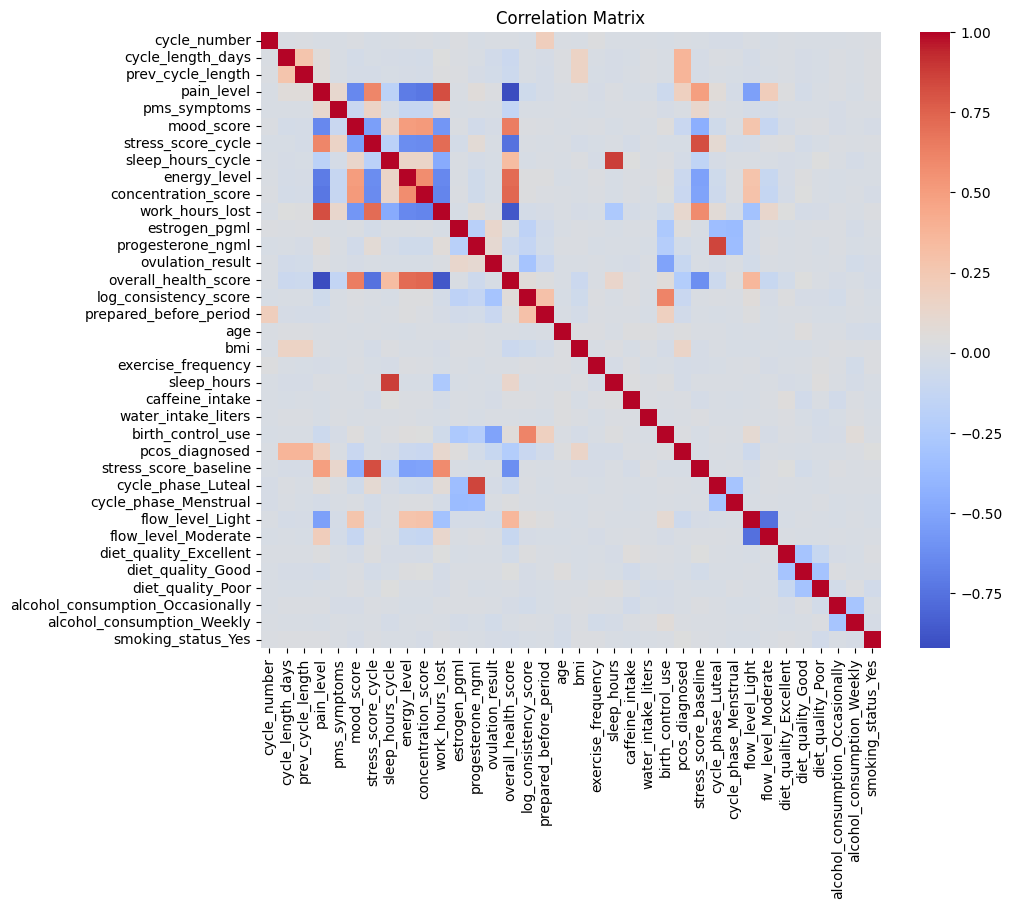

In [ ]:
# Check correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(merged_data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

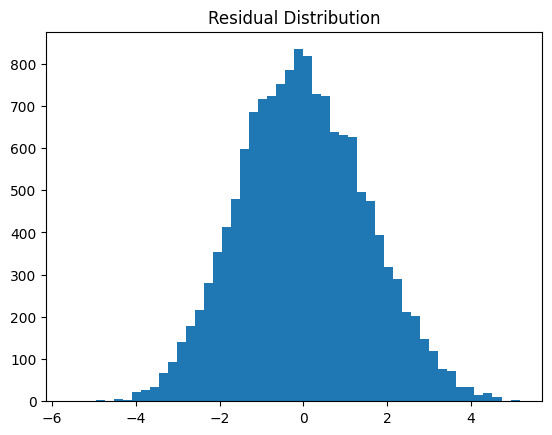

In [ ]:
# Residual plot
import matplotlib.pyplot as plt

residuals = model4.resid

plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.show()

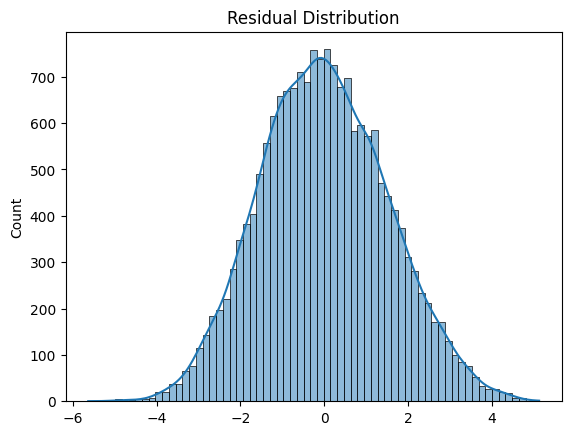

In [ ]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

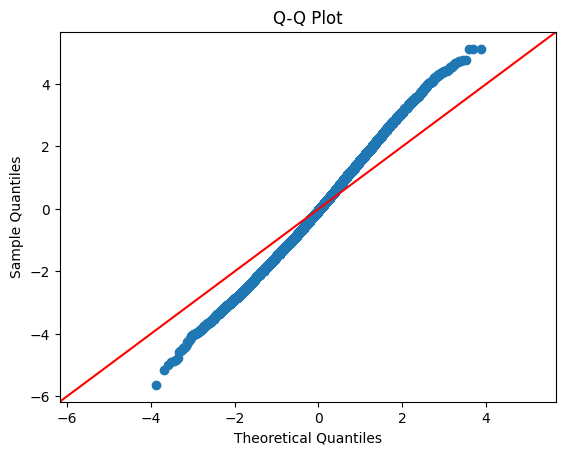

In [ ]:
import statsmodels.api as sm

sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()